# DHBW Machine Learning: R2-D2

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.tree import DecisionTreeRegressor, plot_tree

## Buisiness & Data Understanding

### Überblick über den Datensatz




#### Problembeschreibung
In Bike-Sharing-Systemen besteht das zentrale Problem darin, die richtige Anzahl an Fahrrädern zur richtigen Zeit bereitzustellen. Wenn zu wenige Fahrräder zur Verfügung stehen, gibt es unzufriedene Kunden und verlorene Nachfrage, während das Problem bei zu vielen Fahrrädern eine ineffiziente Ressourcennutzung und höhere Kosten mit sich bringt. Das Ziel ist daher eine Vorhersage für die stündliche Nachfrage. 

#### Anwendungskontext
In vielen Großstädten weltweit wie z.B. in Seoul wurden Bike-Sharing-Systeme eingeführt, um den Verkehr zu entlasten, die nachhaltige Mobilität zu födern und bequemer zu machen und die letzte Strecke im öffentlichen Verkehr abzudecken. Das operative Problem ist die Frage, wie viele Fahrräder müssen zu einem bestimmten Zeitpunkt bereitstehen, um die Nachfrage zu bedienen. Denn die Nutzer erwarten sofortige Verfügbarkeit. Fehlende Fahrräder führen zur Frustation, mehr Wartezeit als geplant und die Abwanderung zu Alternativen. Gleichzeitig führen aber zu viele Fahrräder an einem Standort zur ineffizienten Nutzung. Die Nachfrage ist schwankend und wird beeinflusst durch die durch zeitliche Faktoren, Wetterbedingungen und saisonale Effekte. 
#### Zielsetzung
Ziel es deshalb, die Prognose der stündlich benötigten Fahrradanzahl, um eine zuverlässige und kontinuierliche Verfügbarkeit von Mietfahrrädern zu gewährleisten.
#### Erfolgskriterien
Business Kriterien: Reduktion von Leerständen und Engpässen, höhere Kundenzufriedenheit, effizientere Nutzung
Data Mining Kriterien: Geringer Prognosefehler

#### Überblick über den Datensatz und die Variablen

Der Datensatz besteht aus 8760 Beobachtungen(stündlich für ein Jahr) im Zeitraum von Dezember 2017 bis Dezember 2018. DIe Zielvariable ist der " Rented Bike Count " (Anzahl gemieteter Fahrräder pro Stunde). Der Datentyp ist multivariat. Es handelt sich um einen multivariaten Datensatz, der im Kontext eines Regressionsproblems analysiert wird.

##### Variablenübersicht
Zeitvariablen: Date, Hour 
Wettervariablen: Temperature, Humidity, Wind speed, Visibility, Dew point temperature, Solar radiation, Rainfall, Snowfall
Kontextvariablen: Seasons, Holiday, Functioning Day

##### Datentypen
Numerisch: Rented Bike Count (Zielvariable), Temperature, Humidity, Wind speed, Visibility, Dew point temperature, Solar radiation, Rainfall, Snowfall
Kategorisch: Seasons, Holiday, Functioning Day
Zeitvariablen: Date, Hour

#### Explorative Datenanalyse
Im Rahmen der explorativen Datenanalyse wurde der Datensatz untersucht, um zentrale Muster und Einflussfaktoren auf die Zielvariable „Rented Bike Count“ zu identifizieren. Dabei zeigt sich, dass die Nachfrage nach Mietfahrrädern stark variiert und typischerweise rechtsschief verteilt ist, mit wenigen hohen Spitzenwerten.
Ein wesentlicher Einflussfaktor ist die Zeit. Die Nachfrage weist klare tägliche Muster auf, mit Peaks in den Morgen- und Abendstunden (Pendlerverkehr) sowie niedriger Nutzung in der Nacht. Zudem unterscheiden sich Werktage und Wochenenden, wobei an Werktagen ausgeprägtere Nutzungsspitzen auftreten.
Auch Wetterbedingungen spielen eine zentrale Rolle. Die Temperatur korreliert positiv mit der Nachfrage, während Niederschlag und Schneefall diese deutlich reduzieren. Saisonale Effekte sind ebenfalls erkennbar, im Sommer ist die Nutzung höher als im Winter.

In [2]:
data = pd.read_csv("SeoulBikeData.csv")
data.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [36]:
data.describe()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


## Data Preparation

### Umgang mit fehlenden Werten

In diesem Datensatz sind keine fehlende Werte vorhanden.

In [3]:
data.isna().values.any()

np.False_

### Codierung von Variablen
Date wird entfernt, da relevante Informationen durch `Temperatur`,`Season` und `Holiday` gegeben sind.

`Season`,`Holiday` und `Functioning Day` werden mit Dummy Variablen initialisiert.

In [4]:
data = data.drop(columns="Date")

In [5]:
data_encoded = pd.get_dummies(
    data=data, columns=["Seasons", "Holiday", "Functioning Day"], drop_first=True
)

In [6]:
max_hour = 24

data_encoded['hour_sin'] = np.sin(2*np.pi * data_encoded['Hour'] / max_hour)

data_encoded['hour_cos'] = np.cos(2*np.pi * data_encoded['Hour'] / max_hour)



### Zielvariable
Die Zielvariable soll die ausgeliehenen Fahrräder an einem gegeben Tag sein.

In [7]:
target = "Rented Bike Count"
X = data_encoded.drop(columns=[target, 'Hour'])
y = data_encoded[target]

### Aufteilung in Trainings- und Testdaten
Der Split wird in 80% Trainingsdaten und 20% Testdaten erstellt.



In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=17
)

## Modeling
Um alle folgende Modelle zu vergleichen wird die beste Instanz der Modelle gespeichert und am Ende evaluiert. Das beste Modell wird anhand des `neg_mean_squared_error` ermittelt in einem 5-split kfold.

Klassifikationsmodelle werden hier ausgeschlossen da es sich um ein Regressionsproblem handelt. Diese sind für Kategorien (Ja/Nein) gedacht. Wir wollen aber eine exakte Menge an Rädern vorhersagen, keine Klasse.

In [9]:
best_models = {}

In [10]:
kfold = KFold(n_splits=5, shuffle=True, random_state=17)

### Linear Regression

In [11]:

lr_model = LinearRegression()
cv_scores = cross_val_score(
    lr_model, X_train, y_train, cv=kfold, scoring="neg_mean_squared_error"
)
cv_error = -cv_scores.mean()
np.sqrt(cv_error)

np.float64(434.8279195800911)

In [12]:
best_models["linear_regression"]=LinearRegression().fit(X_train,y_train)

### Lasso


In [13]:
lasso_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(max_iter=10000)) 
])

param_grid_lasso = {'lasso__alpha': [0.1, 1.0, 5.0, 10.0, 20.0]}

In [14]:
lasso_grid = GridSearchCV(lasso_pipe, param_grid_lasso, cv=kfold, scoring="neg_mean_squared_error")
lasso_grid.fit(X_train, y_train)

lasso_rmse = np.sqrt(-lasso_grid.best_score_)
print(f"Bester Lasso RMSE: {lasso_rmse}")
best_models["lasso"] = lasso_grid.best_estimator_

Bester Lasso RMSE: 434.82869551758546


### Ridge

In [15]:

ridge_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])
param_grid_ridge = {'ridge__alpha': [0.1, 1.0, 10.0, 100.0, 500.0]}


In [16]:

ridge_grid = GridSearchCV(ridge_pipe, param_grid_ridge, cv=kfold, scoring="neg_mean_squared_error")
ridge_grid.fit(X_train, y_train)


ridge_rmse = np.sqrt(-ridge_grid.best_score_)
print(f"Bester Ridge RMSE: {ridge_rmse}")

best_models["ridge"] = ridge_grid.best_estimator_


Bester Ridge RMSE: 434.82630111330275


### Polynomiale Regression


Da wir vermuten, dass Variablen wie die Temperatur keinen rein linearen Effekt haben (zu kalt = wenig Räder, perfekt = viele Räder, zu heiß = wieder weniger), erweitern wir das Modell um polynomielle Features.

In [17]:
polypipe = Pipeline([
    ("polynomial", PolynomialFeatures(include_bias=False)),
    ("linear_regression", LinearRegression())
])


In [18]:
grid_search = GridSearchCV(
    estimator=polypipe,
    param_grid={
        "polynomial__degree": [1,2,3],
    },
    cv=kfold,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'polynomial__degree': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the scor

In [19]:
best_models["polynomial_regression"]=grid_search.best_estimator_

### Regression Tree

In [20]:
tree = DecisionTreeRegressor(
    random_state = 42,
    max_depth=3
) 

In [21]:
tree.fit(X_train,y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

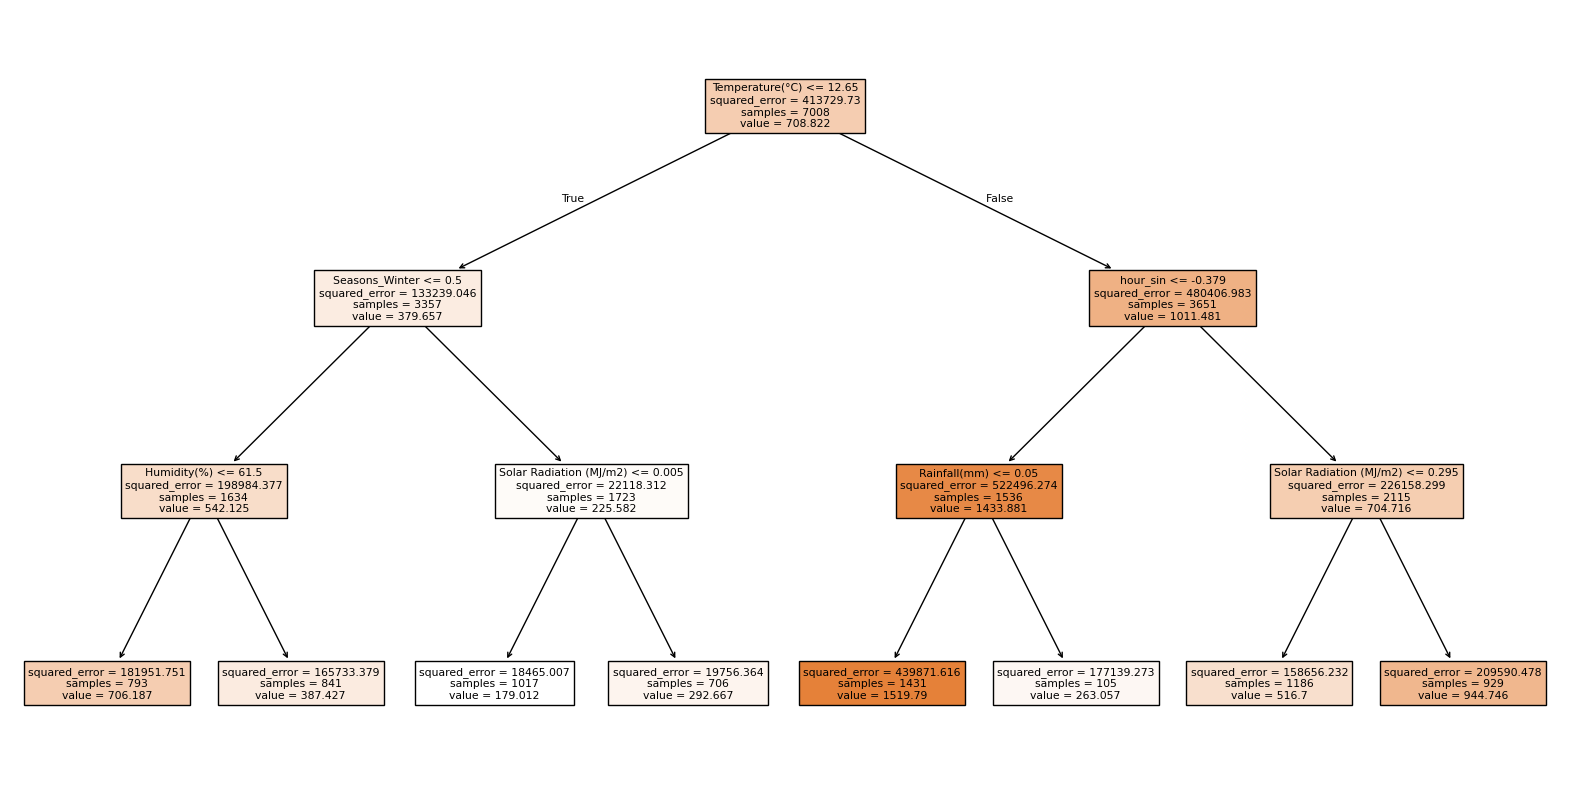

In [22]:
plt.figure(figsize=(20, 10))
plot_tree(tree, filled=True, feature_names=X.columns)
plt.show()

#### Pruning

In [23]:
fulltree = DecisionTreeRegressor(
    random_state=42
)
path = fulltree.cost_complexity_pruning_path(X_train,y_train)
ccp_alphas = path.ccp_alphas[:-1:100] #Reduktion auf 1/100 der Werte aufgrund von Laufzeit und Ähnlichkeit der Werte (6100+ -> 61)
ccp_alphas.shape


(62,)

In [24]:
grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=17),
    param_grid={"ccp_alpha": ccp_alphas},
    cv=kfold,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeR...ndom_state=17)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{'ccp_alpha': array([0.0000...13069125e+02])}
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : 

In [25]:
best_models["decision_tree"]=grid_search.best_estimator_


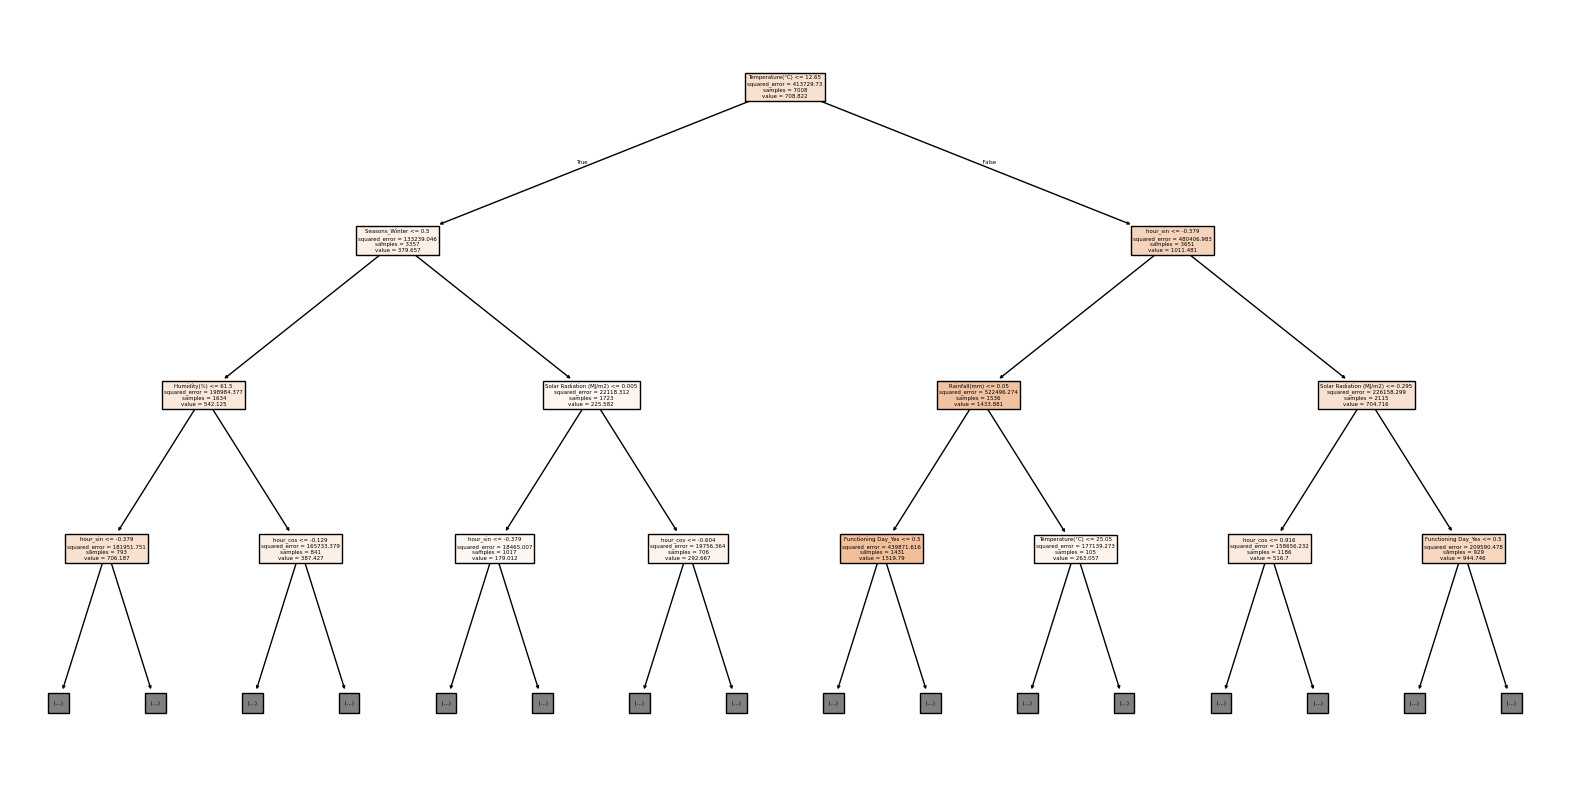

In [26]:
plt.figure(figsize=(20, 10))
plot_tree(grid_search.best_estimator_, filled=True, feature_names=X.columns,max_depth=3)
plt.show()

In [27]:
rand=RandomForestRegressor(random_state=17)

In [28]:
grid_search = GridSearchCV(
    estimator=rand,
    param_grid={
        "n_estimators": np.linspace(100, 200, 2, dtype=int),
        "max_depth": np.linspace(10, 20, 4, dtype=int),
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["log2", "sqrt"],
    },
    cv=kfold,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=17)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': array([10, 13, 16, 20]), 'max_features': ['log2', 'sqrt'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the

In [29]:
best_models["random_forest"]=grid_search.best_estimator_

### Boosting


In [30]:
gbr_model = HistGradientBoostingRegressor(           
    random_state=17
)

param_grid_gbr = {
    'max_depth':[5,7], 
    'learning_rate': [0.01, 0.05],
    'max_iter': [200,300],
    'max_leaf_nodes': [60, 50,70],
    'l2_regularization': [0.0, 1.0, 10.0]
}

grid_gbr = GridSearchCV(HistGradientBoostingRegressor(random_state=17), 
                        param_grid_gbr, cv=kfold, scoring='neg_mean_squared_error', n_jobs=-1)
grid_gbr.fit(X_train, y_train)

print(f"Beste Parameter: {grid_gbr.best_params_}")
best_models["gradient_boosting"] = grid_gbr.best_estimator_


Beste Parameter: {'l2_regularization': 1.0, 'learning_rate': 0.05, 'max_depth': 7, 'max_iter': 300, 'max_leaf_nodes': 60}


In [31]:
test_errors =[root_mean_squared_error(y_test,model.predict(X_test)) for model in best_models.values()]
test_errors


[437.6733188703213,
 437.6588977478243,
 437.65707753118767,
 315.675796941516,
 291.81808131821464,
 232.34439470386394,
 220.34782958986523]

In [32]:
train_errors = [
    root_mean_squared_error(y_train, model.predict(X_train))
    for model in best_models.values()
]
train_errors

[433.60209660499066,
 433.60292695662343,
 433.6024282224746,
 298.51125772597817,
 202.79379219383944,
 89.93143429127109,
 147.88038328963702]

### Verleich der Test- und Trainingsfehler

In [33]:
model_names = list(best_models.keys())

comparison_data = {
    "Model": model_names,
    "Train RMSE": train_errors,
    "Test RMSE": test_errors,
    "Delta (Overfitting-Indikator)": [test - train for train, test in zip(train_errors, test_errors)]
}
comparison_df = pd.DataFrame(comparison_data)
comparison_df

,Model,Train RMSE,Test RMSE,Delta (Overfitting-Indikator)
0,linear_regression,433.602097,437.673319,4.071222
1,lasso,433.602927,437.658898,4.055971
2,ridge,433.602428,437.657078,4.054649
3,polynomial_regression,298.511258,315.675797,17.164539
4,decision_tree,202.793792,291.818081,89.024289
5,random_forest,89.931434,232.344395,142.412960
6,gradient_boosting,147.880383,220.347830,72.467446


#### Vergleich der Modelle

| Linear Regression | Polynomial Regression | Decision Tree| Random Forest |Ridge|
| ----------------- | --------------------- |--------------|---------------|-----|
|hoher Bias | hoher Bias| hohe Varianz |sehr hohe Varianz |
| Underfitting|Underfitting |Overfitting| Overfitting |

### Evaluation


Das final gewählte Modell ist der Decision Tree, da dieser den besten Bias-Variance-Tradeoff hat. 